# detecting — fixed single walk (theory vs measured)

**Purpose**: For a run where `walk_list_normal.csv` has **exactly one** walk (`NWALKS=1` in `run_detecting_expr2_interval.sh` / `run_detecting_expr3_frkern.sh`, or equivalent), compare:

- **Theory**: synthetic samples from **Normal(mu_ns, sigma_rel × mu_ns)** with `sigma_rel` matching `TacVar/utils/gen_walklist.py` default (`0.015`). `mu_ns` is resolved from the combo directory name (`interval*`), then `meta.md` (`walk_mu_ns` / `walk_fixed_ns` / `interval_ns`), then the single row `ta_ns` in the CSV.
- **Measured**: all `partes_ta_r*.csv` samples under the single walk directory `<timer>_walks/w0000_ta*/`.

**Layout**: [`EXP_ROOT/walk_list_normal.csv`](.) from `run_detecting_expr*.sh` (shared at timestamp root), or legacy path under `<timer>/<combo>/`.

Adjust **cell 1** (`DATA_ROOT`, `HOSTNAME`, `EXPR_NAME`, `TIMESTAMP`, combo filters, **`DROP`** for plot trimming).

- **`DROP`** (default `0.995`): keep values with `x <= quantile(x, DROP)` for both theory and measured series before plotting; set `1.0` to disable. Roughly drops the upper `100×(1−DROP)%` of the sample mass.

In [21]:
from __future__ import annotations

from pathlib import Path
import re
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================
# Hyperparameters
# =========================

DATA_ROOT = Path("/astrum/home/hpchzy/code/data")

DATETIME = "20260416"




HOSTNAME = "cgnr6760pn2"
EXPR_NAME = "detecting.expr1.timer.fixed"
TIMESTAMP = "20260416_144646" # 原方法，不锁频，2048KB


EXP_ROOT = Path(f"{DATA_ROOT}/{DATETIME}/output/{HOSTNAME}/{EXPR_NAME}/{TIMESTAMP}")
print(f"EXP_ROOT: {EXP_ROOT.resolve()}")

WALK_LIST_NAME = "walk_list_normal.csv"
PLOT_TITLE_EXPR = EXPR_NAME

FSIZE_KIB: int | None = None
INTERVAL_NS: int | None = None
FKERN: str | None = None
RKERN: str | None = None
RSIZE_KIB: int | None = None

# Theory: same convention as gen_walklist.py --dist normal (sigma_rel × mu)
SIGMA_REL = 0.015
N_THEORY = 50_000
SEED = 42

# Upper-tail trim: keep x <= quantile(x, DROP); e.g. DROP=0.995 drops ~top 0.5%
DROP = 0.995
QUANTILE_KEEP = DROP  # passed to trim_upper_tail

# Histogram overlay
HIST_BINS = 80
HIST_ALPHA = 0.45

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

EXP_ROOT: /astrum/home/hpchzy/code/data/20260416/output/cgnr6760pn2/detecting.expr1.timer.fixed/20260416_144646


In [22]:
def _parse_combo(combo_name: str) -> dict[str, str]:
    out: dict[str, str] = {}
    for part in combo_name.split("_"):
        if not part:
            continue
        for k in ("interval", "fkern", "rkern", "fsize", "rsize"):
            if part.startswith(k):
                out[k] = part[len(k) :]
                break
    return out


def combo_dir_matches(
    combo_name: str,
    *,
    fsize_kib: int | None,
    interval_ns: int | None,
    fkern: str | None,
    rkern: str | None,
    rsize_kib: int | None,
) -> bool:
    info = _parse_combo(combo_name)
    if interval_ns is not None and int(info.get("interval", "-1")) != int(interval_ns):
        return False
    if fsize_kib is not None and int(info.get("fsize", "-1")) != int(fsize_kib):
        return False
    if fkern is not None and info.get("fkern") != str(fkern):
        return False
    if rkern is not None and info.get("rkern") != str(rkern):
        return False
    if rsize_kib is not None:
        parsed = info.get("rsize")
        if parsed is None:
            return int(rsize_kib) == 0
        if int(parsed) != int(rsize_kib):
            return False
    return True


def list_timers(exp_root: Path) -> list[str]:
    timers: list[str] = []
    for p in sorted(exp_root.iterdir()):
        if not p.is_dir() or p.name.startswith("."):
            continue
        if p.name == "_archive":
            continue
        for combo in p.iterdir():
            if not combo.is_dir():
                continue
            walks = combo / f"{p.name}_walks"
            if walks.is_dir():
                timers.append(p.name)
                break
    return timers


def combo_dirs_for_timer(
    exp_root: Path,
    timer: str,
    *,
    fsize_kib: int | None,
    interval_ns: int | None,
    fkern: str | None,
    rkern: str | None,
    rsize_kib: int | None,
) -> list[Path]:
    base = exp_root / timer
    if not base.is_dir():
        return []
    out: list[Path] = []
    for combo in sorted(base.iterdir()):
        if not combo.is_dir():
            continue
        if not combo_dir_matches(
            combo.name,
            fsize_kib=fsize_kib,
            interval_ns=interval_ns,
            fkern=fkern,
            rkern=rkern,
            rsize_kib=rsize_kib,
        ):
            continue
        walks = combo / f"{timer}_walks"
        if not walks.is_dir():
            continue
        out.append(combo)
    return out


def load_experiment_meta(meta_dir: Path) -> dict[str, str]:
    out: dict[str, str] = {}
    p_txt = meta_dir / "meta.txt"
    if p_txt.is_file():
        for line in p_txt.read_text().splitlines():
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            k, _, v = line.partition("=")
            out[k.strip()] = v.strip()
    p_md = meta_dir / "meta.md"
    if p_md.is_file():
        for m in re.finditer(
            r"^\|\s*([^|\n]+?)\s*\|\s*`([^`]*)`\s*\|",
            p_md.read_text(),
            re.MULTILINE,
        ):
            k = m.group(1).strip()
            if not k or k in ("Key", "Parameter", "Item") or k.startswith("---"):
                continue
            out[k] = m.group(2).strip()
    return out


def read_walk_dataframe(exp_root: Path, combo_dir: Path) -> tuple[pd.DataFrame, Path]:
    p_root = exp_root / WALK_LIST_NAME
    if p_root.is_file():
        return pd.read_csv(p_root), p_root
    p_combo = combo_dir / WALK_LIST_NAME
    if p_combo.is_file():
        return pd.read_csv(p_combo), p_combo
    raise FileNotFoundError(f"No {WALK_LIST_NAME} under {exp_root} or {combo_dir}")


def assert_single_walk(walk_df: pd.DataFrame) -> None:
    n = len(walk_df.index)
    if n != 1:
        raise ValueError(
            f"Expected exactly 1 row in walk list (single-walk run), got {n}. "
            "Set NWALKS=1 in the detecting script or pick another timestamp."
        )


def resolve_mu_ns(combo_path: Path, walk_df: pd.DataFrame) -> float:
    info = _parse_combo(combo_path.name)
    if "interval" in info:
        return float(info["interval"])
    meta = load_experiment_meta(combo_path)
    for k in ("walk_mu_ns", "walk_fixed_ns", "interval_ns"):
        v = meta.get(k)
        if v is not None and str(v).strip() != "":
            return float(v)
    return float(walk_df["ta_ns"].iloc[0])


def single_walk_dir(timer: str, combo: Path) -> Path:
    root = combo / f"{timer}_walks"
    dirs = sorted(p for p in root.glob("w*") if p.is_dir())
    if len(dirs) != 1:
        raise ValueError(
            f"Expected exactly 1 walk directory under {root}, found {len(dirs)}. "
            "Does this run use NWALKS=1?"
        )
    return dirs[0]


def load_ta_samples(walk_dirs: list[Path]) -> np.ndarray:
    blocks: list[np.ndarray] = []
    for wd in walk_dirs:
        for f in sorted(wd.glob("partes_ta_r*.csv")):
            arr = np.loadtxt(f, dtype=np.int64)
            if arr.ndim == 0:
                arr = np.array([arr], dtype=np.int64)
            blocks.append(arr.ravel())
    if not blocks:
        return np.array([], dtype=np.int64)
    return np.concatenate(blocks, axis=0)


def trim_upper_tail(x: np.ndarray, q_keep: float) -> np.ndarray:
    if x.size == 0 or q_keep >= 1.0:
        return x
    cap = float(np.quantile(x, q_keep))
    return x[x <= cap]


def ecdf_p_vs_t(x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    if x.size == 0:
        return np.array([]), np.array([])
    t = np.sort(x.astype(float))
    n = t.size
    p = (np.arange(1, n + 1) - 0.5) / n
    return p, t

In [23]:
# =========================
# Load walk list + measured ta (single walk per timer)
# =========================

exp_root = Path(EXP_ROOT).resolve()
_combo_kw = dict(
    fsize_kib=FSIZE_KIB,
    interval_ns=INTERVAL_NS,
    fkern=FKERN,
    rkern=RKERN,
    rsize_kib=RSIZE_KIB,
)

timers = list_timers(exp_root)
if not timers:
    raise RuntimeError(f"No timer directories under {exp_root}")

ref_timer = timers[0]
combos_ref = combo_dirs_for_timer(exp_root, ref_timer, **_combo_kw)
if not combos_ref:
    raise RuntimeError("No combo matches filters for reference timer " + ref_timer)

combo_name = combos_ref[0].name
combo_ref = combos_ref[0]

walk_df, walk_path = read_walk_dataframe(exp_root, combo_ref)
assert_single_walk(walk_df)
mu_ns = resolve_mu_ns(combo_ref, walk_df)
sigma_abs = float(mu_ns) * float(SIGMA_REL)

exp_meta = load_experiment_meta(combo_ref)

measured_by_timer: dict[str, np.ndarray] = {}
for tm in timers:
    combo_tm = exp_root / tm / combo_name
    if not combo_tm.is_dir():
        print(f"[skip] missing combo dir for timer={tm}: {combo_tm}")
        continue
    wd = single_walk_dir(tm, combo_tm)
    measured_by_timer[tm] = load_ta_samples([wd])

print("walk_list:", walk_path)
print("mu_ns:", mu_ns, "| sigma_rel:", SIGMA_REL, "| sigma_abs:", sigma_abs)
print("combo:", combo_name)
for tm, arr in measured_by_timer.items():
    print(f"  {tm}: n_measured={arr.size}")

walk_list: /astrum/home/hpchzy/code/data/20260416/output/cgnr6760pn2/detecting.expr1.timer.fixed/20260416_144646/walk_list_normal.csv
mu_ns: 10000.0 | sigma_rel: 0.015 | sigma_abs: 150.0
combo: interval10000_fkerncopy_rkernnone_fsize2048
  clock_gettime: n_measured=6400
  likwid: n_measured=6400
  mpi_wtime: n_measured=6400
  papi: n_measured=6400
  papix6: n_measured=6400
  tsc_asym: n_measured=6400


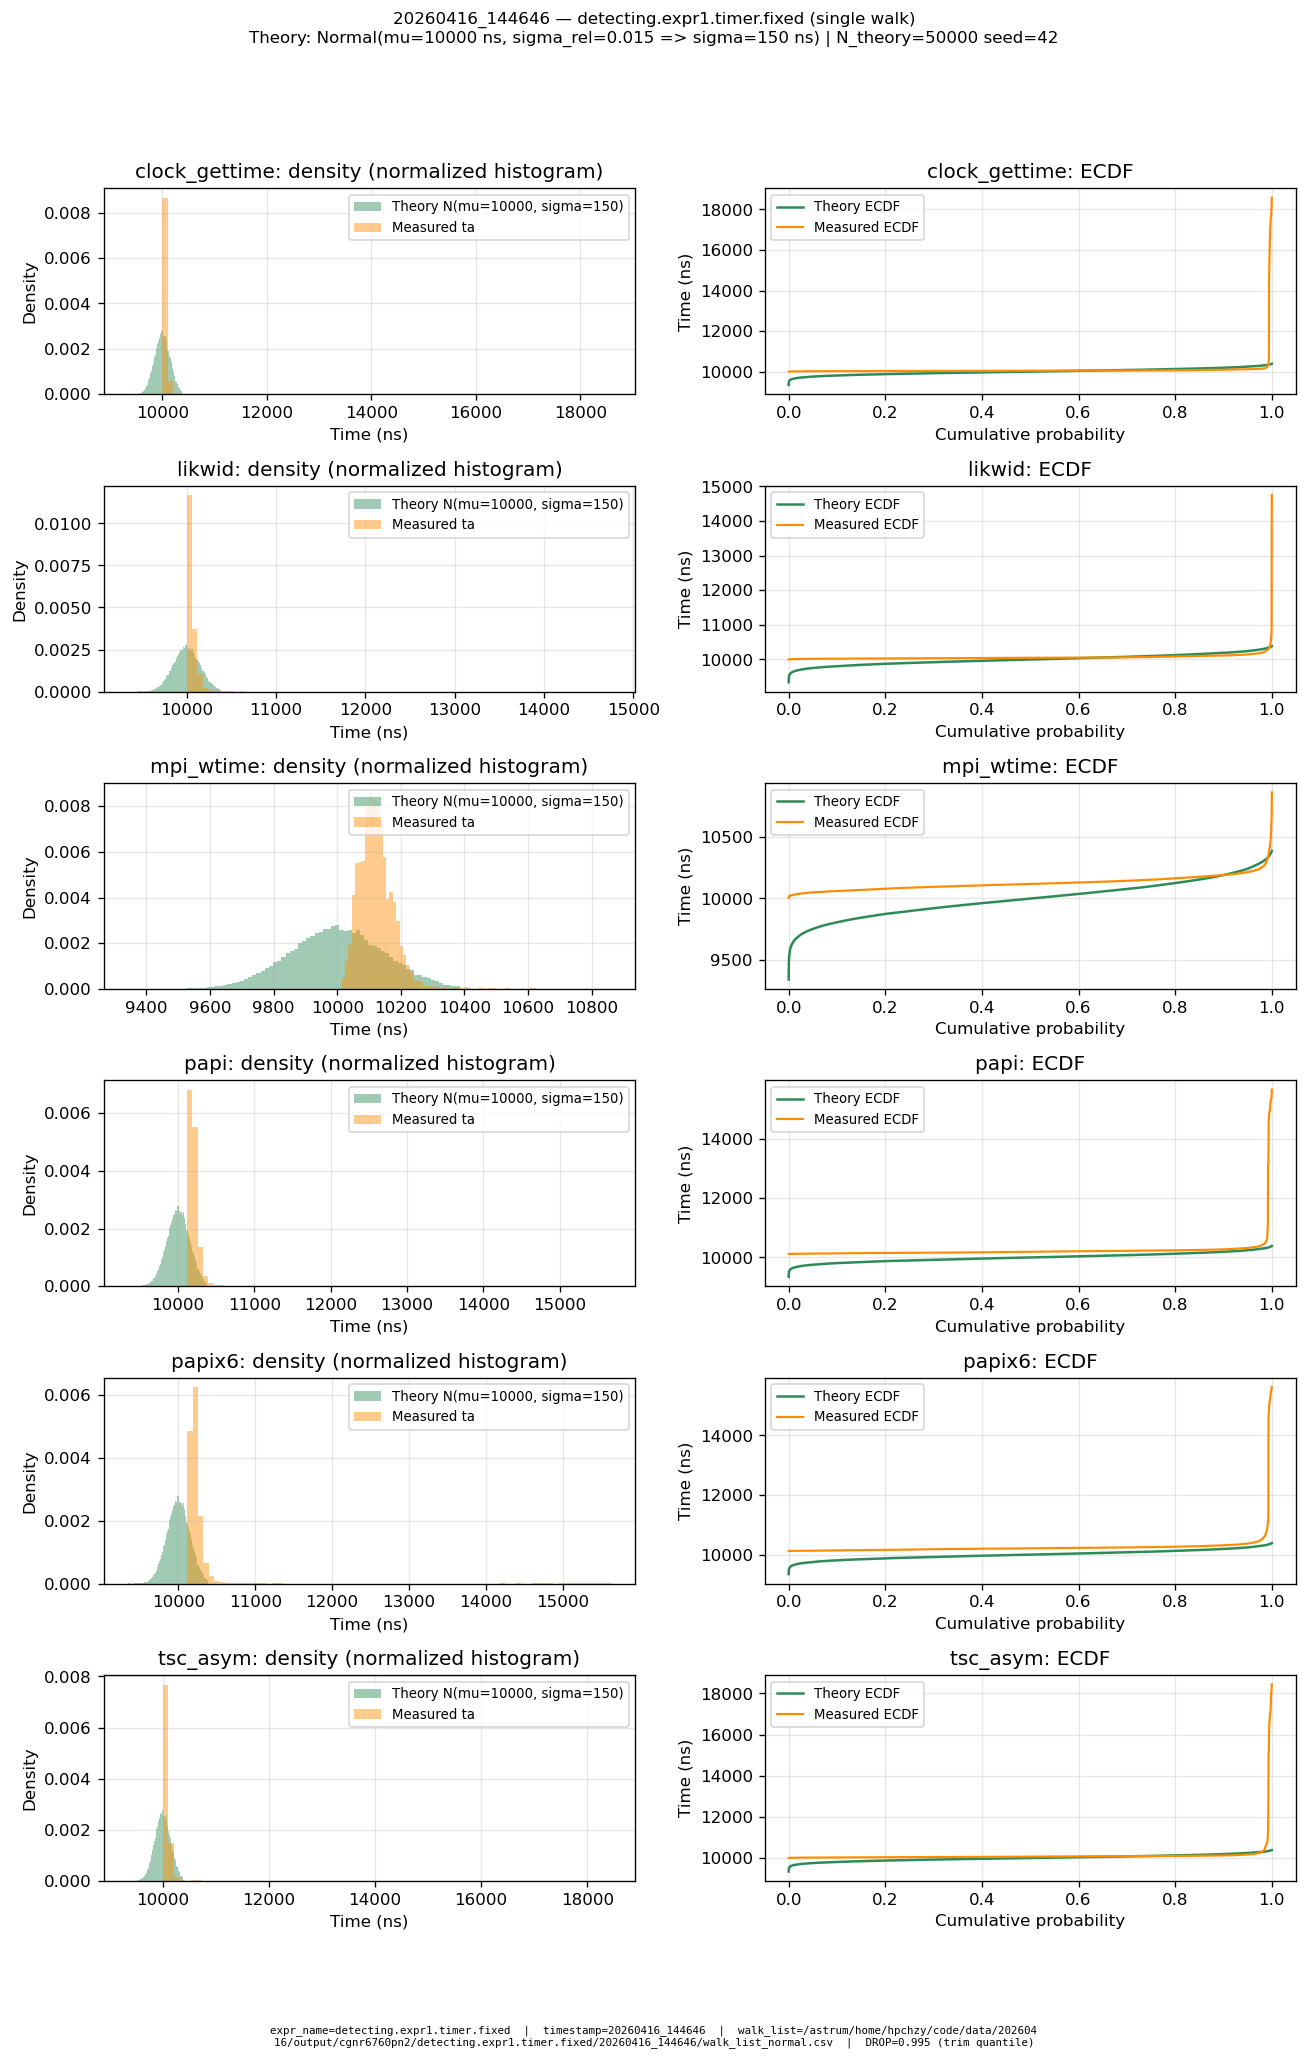

In [24]:
# =========================
# Synthetic theory samples + overlay plots
# =========================

rng = np.random.default_rng(SEED)
theory_raw = rng.normal(float(mu_ns), float(sigma_abs), size=int(N_THEORY))

theory_plot = trim_upper_tail(theory_raw.astype(np.float64), QUANTILE_KEEP)

plot_timers = [tm for tm in timers if tm in measured_by_timer and measured_by_timer[tm].size]
if not plot_timers:
    raise RuntimeError("No measured samples loaded for any timer")

n = len(plot_timers)
fig, axes = plt.subplots(n, 2, figsize=(11, 2.8 * n), squeeze=False)

meta_line = "  |  ".join(
    f"{k}={exp_meta[k]}"
    for k in ("expr_name", "timestamp")
    if k in exp_meta
)
subtitle = (
    f"Theory: Normal(mu={mu_ns:g} ns, sigma_rel={SIGMA_REL} => sigma={sigma_abs:.4g} ns) | "
    f"N_theory={N_THEORY} seed={SEED}"
)

for i, tm in enumerate(plot_timers):
    meas_raw = measured_by_timer[tm].astype(np.float64)
    meas_plot = trim_upper_tail(meas_raw, QUANTILE_KEEP)

    ax_h, ax_e = axes[i, 0], axes[i, 1]
    ax_h.hist(
        theory_plot,
        bins=HIST_BINS,
        density=True,
        alpha=HIST_ALPHA,
        color="seagreen",
        label=f"Theory N(mu={mu_ns:g}, sigma={sigma_abs:.4g})",
    )
    ax_h.hist(
        meas_plot,
        bins=HIST_BINS,
        density=True,
        alpha=HIST_ALPHA,
        color="darkorange",
        label="Measured ta",
    )
    ax_h.set_xlabel("Time (ns)")
    ax_h.set_ylabel("Density")
    ax_h.set_title(f"{tm}: density (normalized histogram)")
    ax_h.legend(loc="upper right", fontsize=8)
    ax_h.grid(True, alpha=0.3)

    p_th, t_th = ecdf_p_vs_t(theory_plot)
    p_m, t_m = ecdf_p_vs_t(meas_plot)
    ax_e.plot(p_th, t_th, color="seagreen", linewidth=1.5, label="Theory ECDF")
    ax_e.plot(p_m, t_m, color="darkorange", linewidth=1.3, label="Measured ECDF")
    ax_e.set_xlabel("Cumulative probability")
    ax_e.set_ylabel("Time (ns)")
    ax_e.set_title(f"{tm}: ECDF")
    ax_e.legend(loc="upper left", fontsize=8)
    ax_e.grid(True, alpha=0.3)

fig.suptitle(
    f"{exp_root.name} — {PLOT_TITLE_EXPR} (single walk)\n{subtitle}",
    fontsize=10,
    y=1.02,
)
footer = textwrap.fill(
    meta_line + f"  |  walk_list={walk_path}  |  DROP={DROP} (trim quantile)",
    width=118,
)
fig.text(0.5, 0.01, footer, ha="center", va="bottom", fontsize=6.5, family="monospace")
fig.tight_layout(rect=[0, 0.06, 1, 0.98])
plt.show()